# Los Alamos 3-storey building — three-head damage diagnosis

<a href="https://colab.research.google.com/github/grcarmenaty/pymodal/blob/master/examples/los_alamos_3story/los_alamos_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook walks the **full pymodal pipeline** on the LANL 3-storey
benchmark, using the rail-constrained, screw-bolted geometry and progressive
column thinning as the damage descriptor.

| step | what it does |
|---|---|
| 1 | build geometry: 4 plates + 12 columns + 32 screws (2 per junction); columns terminate at mid-plate thickness everywhere; the base sits on rails along Y |
| 2 | enumerate 49 damage scenarios = 1 pristine + 12 columns × 4 severity levels (75 %, 50 %, 25 %, 10 % of nominal section) |
| 3 | shaker at the centre of the base plate in Y; 16 accelerometers, one at every column–plate intersection, all in Y |
| 4 | build a 4 900-sample labelled `pymodal.frf` collection (100 small geometric variations per scenario), persisted to a single HDF5 file |
| 5 | train **three** classification heads on the same FRFs: detection (pristine vs damaged), localisation (which of 12 columns), severity (4 thinning levels) |
| 6 | report three confusion matrices |

The mesh-agnostic plumbing — `pymodal.Scenario`, `pymodal.ParameterVariation`,
`pymodal.build_frf_collection` — now lives in the **library**
(`pymodal/scenarios.py`); only the LANL-specific scenario factory and base
geometry stay in this example. To repurpose this workflow for any other
mesh, replace the `BuildingGeometry` factory and pass an FEA modal provider;
everything else stays as-is.


## Setup


In [ ]:
# ── Colab-ready setup ──
# - Installs pymodal from GitHub on a fresh runtime (Colab, Binder, …).
# - On Colab, also clones the repo so example sibling modules are importable.
# - Idempotent: re-running on a warm kernel is a fast no-op.
import os, sys, subprocess, inspect
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/grcarmenaty/pymodal.git"
REPO_BRANCH = "master"

def _has_post_refactor_api():
    try:
        import pymodal
        return "path" in inspect.signature(pymodal.frf.__init__).parameters
    except Exception:
        return False

if not _has_post_refactor_api():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pyFRF>=0.40", "pint>=0.20.1",
                           "audiomentations>=0.31.0", "h5py"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--no-deps", "--force-reinstall", "--no-cache-dir",
                           f"git+{REPO_URL}@{REPO_BRANCH}"])

if IN_COLAB:
    repo_dir = Path("/content/pymodal-repo")
    if not repo_dir.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
                               "--branch", REPO_BRANCH, REPO_URL, str(repo_dir)])
    os.chdir(repo_dir / "examples/los_alamos_3story")
    print(f"chdir → {os.getcwd()}")

if not _has_post_refactor_api():
    print("pymodal installed; restarting kernel to pick up new packages...")
    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
    raise SystemExit("Kernel restart triggered — re-run this cell after restart.")

import pymodal
print(f"pymodal {pymodal.__version__} ready (post-refactor API).")


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

HERE = Path(os.getcwd()).resolve()
EXAMPLE_DIR = HERE / "examples" / "los_alamos_3story" if (HERE / "examples").exists() else HERE
REPO_ROOT = EXAMPLE_DIR.parent.parent
for p in (str(REPO_ROOT), str(EXAMPLE_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

import params as P
import reduced_model as RM
import damage_scenarios as DS
import pymodal

print("pymodal", pymodal.__version__,
      "  N_STORIES =", P.N_STORIES,
      "  rails along", P.RAIL_DIRECTION,
      "  total scenarios =", 1 + 4 * P.N_STORIES * len(DS.DAMAGE_LEVELS))


pymodal 0.2.0   N_STORIES = 3   rails along Y   total scenarios = 49


## 1. Geometry

* every column terminates at the mid-thickness of every plate it joins, so
  two columns meet inside every intermediate plate and the base / top
  columns also stop at mid base / roof;
* every column–plate junction is bolted with **two** cylindrical screws
  offset symmetrically along the column wide direction;
* the bottom face of the base plate sits on rails along **Y** — `DX = 0,
  DZ = 0`, all rotations locked, only `DY` is free;
* the columns' thin side is along Y, so the building moves along the
  columns' soft direction, exactly the LANL benchmark setup.


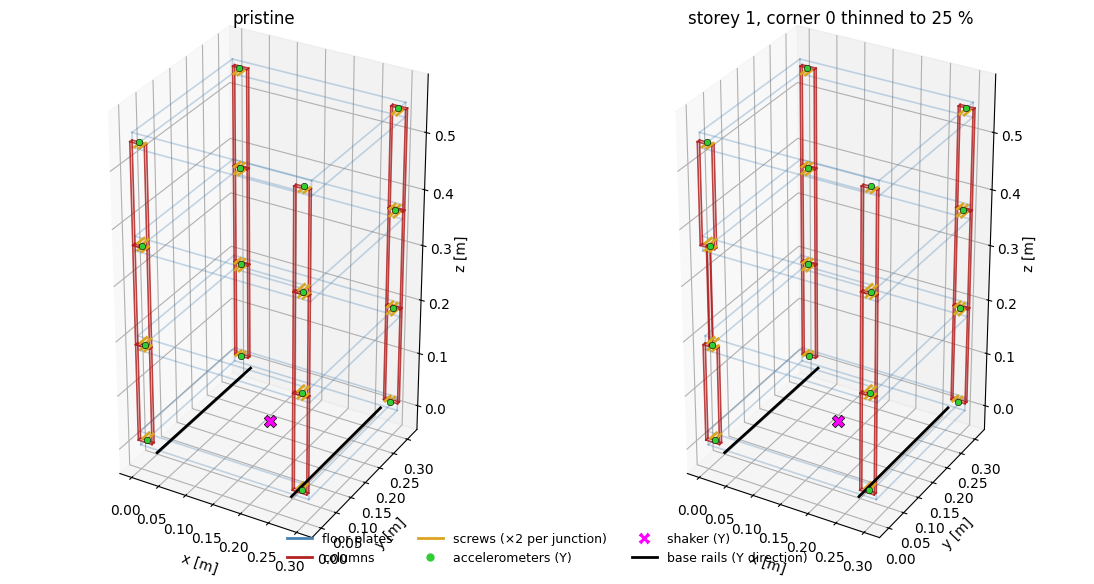

In [2]:
def _draw_box(ax, x0, y0, z0, dx, dy, dz, color, alpha, lw=1.2):
    import itertools
    pts = np.array(list(itertools.product([x0, x0+dx], [y0, y0+dy], [z0, z0+dz])))
    edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
    for a, b in edges:
        ax.plot(*zip(pts[a], pts[b]), color=color, alpha=alpha, linewidth=lw)


def plot_building(geom, ax=None, title=None, show_screws=True, show_sensors=True):
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
    box_centres = geom.column_box_centres()
    attach_points = geom.column_attachment_points()
    # plates
    for k in range(geom.n_stories + 1):
        z0 = k * geom.storey_height
        _draw_box(ax, 0, 0, z0, geom.plate_lx, geom.plate_ly, geom.plate_lz,
                   color='steelblue', alpha=0.30)
    # columns (external, with thinning)
    for s in range(geom.n_stories):
        z_start, z_end = P.column_z_extent(s)
        for c, (xc, yc) in enumerate(box_centres):
            f = float(geom.column_factor[s, c])
            if f <= 0:
                continue
            lx = geom.col_lx * f
            ly = geom.col_ly * f
            _draw_box(ax, xc - lx/2, yc - ly/2, z_start,
                       lx, ly, z_end - z_start,
                       color='firebrick', alpha=0.85)
    # screws: drill in Y direction, two per column-plate junction; for
    # each storey segment, lower-end screws sit in the lower plate just
    # above its mid-thickness, upper-end screws in the upper plate just
    # below mid-thickness
    if show_screws:
        z_off = P.SCREW_Z_OFFSET_FRAC * geom.plate_lz
        x_off = P.SCREW_OFFSET_FRAC * geom.col_lx / 2.0
        for s in range(geom.n_stories):
            z_low_centre, z_high_centre = P.column_z_extent(s)
            for c in range(4):
                col_x_centre = box_centres[c, 0]
                col_y_centre = box_centres[c, 1]
                attach_y     = attach_points[c, 1]
                # screw goes from column outer face (further from plate) to
                # SCREW_PLATE_DEPTH inside the plate's side
                if col_y_centre < attach_y:        # column on -Y side
                    y_outer = col_y_centre - geom.col_ly / 2.0
                    y_inner = attach_y + P.SCREW_PLATE_DEPTH
                else:                              # column on +Y side
                    y_outer = col_y_centre + geom.col_ly / 2.0
                    y_inner = attach_y - P.SCREW_PLATE_DEPTH
                for sign in (-1, +1):
                    x_screw = col_x_centre + sign * x_off
                    for z_screw in (z_low_centre + z_off,
                                     z_high_centre - z_off):
                        ax.plot([x_screw, x_screw],
                                 [y_outer, y_inner],
                                 [z_screw, z_screw],
                                 color='goldenrod', linewidth=2.0)
    # rails: two parallel lines beneath the base plate, along the Y direction
    rail_x = [0.10 * geom.plate_lx, 0.90 * geom.plate_lx]
    for rx in rail_x:
        ax.plot([rx, rx], [0.0, geom.plate_ly], [-0.005, -0.005],
                 color='black', linewidth=2.0)
    # sensors at column-plate attachment points (plate edge), four corners
    # x four plates = 16 channels per direction
    if show_sensors:
        for k in range(geom.n_stories + 1):
            z = geom.plate_z_centre(k)
            for xc, yc in attach_points:
                ax.scatter([xc], [yc], [z], color='limegreen', s=22,
                            edgecolors='black', linewidths=0.4, zorder=10)
    # shaker at base centre
    cx, cy = geom.plate_centroid
    z0 = geom.plate_z_centre(0)
    ax.scatter([cx], [cy], [z0], color='magenta', s=80, marker='X',
                edgecolors='black', linewidths=0.5, zorder=10)
    if title:
        ax.set_title(title)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
    ax.set_box_aspect((geom.plate_lx, geom.plate_ly,
                        geom.n_stories * geom.storey_height + geom.plate_lz))


geom_pristine = RM.BuildingGeometry()
geom_damaged = RM.BuildingGeometry()
geom_damaged.column_factor = geom_damaged.column_factor.copy()
geom_damaged.column_factor[1, 0] = 0.25                  # storey 1, corner 0 thinned

fig = plt.figure(figsize=(11.5, 5.5))
ax1 = fig.add_subplot(121, projection='3d'); plot_building(geom_pristine, ax=ax1, title='pristine')
ax2 = fig.add_subplot(122, projection='3d'); plot_building(geom_damaged, ax=ax2,
                                                          title='storey 1, corner 0 thinned to 25 %')
legend = [Line2D([0],[0], color='steelblue', lw=2, label='floor plates'),
          Line2D([0],[0], color='firebrick', lw=2, label='columns'),
          Line2D([0],[0], color='goldenrod', lw=2, label='screws (×2 per junction)'),
          Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
                  markersize=7, label='accelerometers (Y)'),
          Line2D([0],[0], marker='X', color='w', markerfacecolor='magenta',
                  markersize=10, label='shaker (Y)'),
          Line2D([0],[0], color='black', lw=2, label='base rails (Y direction)')]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9, frameon=False,
            bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(); plt.show()


## 2. Damage scenarios

For every column we step through **four** thinning levels (75 %, 50 %, 25 %,
10 % of nominal). Plus pristine: **49 classes** total. The lateral stiffness
of a uniformly thinned column scales as ``factor**4`` (because both
cross-section dimensions shrink and ``I ∝ a^3 b ∝ factor^4``).


In [3]:
scenarios = DS.los_alamos_scenarios()
is_dmg, col_label, sev_label, factor_label, rig_loss = DS.scenario_meta(scenarios)

print(f"{len(scenarios)} scenarios; first 5 and last 5:")
for sc in scenarios[:5] + scenarios[-5:]:
    print(f"  label {sc.label:>2d}  {sc.name}")
print()
print(f"damage levels (factor of nominal section): {DS.DAMAGE_LEVELS}")
print(f"  stiffness retained K/K0 = factor**4: {[f'{x**4:.4f}' for x in DS.DAMAGE_LEVELS]}")
print(f"  loss of rigidity 1 - K/K0          : {[f'{1-x**4:.4f}' for x in DS.DAMAGE_LEVELS]}")


49 scenarios; first 5 and last 5:
  label  0  pristine
  label  1  s0_c0_lvl0_f75
  label  2  s0_c0_lvl1_f50
  label  3  s0_c0_lvl2_f25
  label  4  s0_c0_lvl3_f10
  label 44  s2_c2_lvl3_f10
  label 45  s2_c3_lvl0_f75
  label 46  s2_c3_lvl1_f50
  label 47  s2_c3_lvl2_f25
  label 48  s2_c3_lvl3_f10

damage levels (factor of nominal section): (0.75, 0.5, 0.25, 0.1)
  stiffness retained K/K0 = factor**4: ['0.3164', '0.0625', '0.0039', '0.0001']
  loss of rigidity 1 - K/K0          : ['0.6836', '0.9375', '0.9961', '0.9999']


## 3. Inputs / outputs

* **Shaker**: one driver at the centre of the base plate, in the rail
  direction (Y).
* **Accelerometers**: one at every column–plate intersection in the rail
  direction. ``(N_STORIES + 1) × 4 = 16`` channels.
* The four sensors on the base plate report identical motion (rigid rail
  translation), but they are still produced - this matches what an
  experimentalist would log.


In [4]:
inputs  = DS.shaker_input()
outputs = DS.column_intersection_outputs()
freq_axis = np.arange(1.0, 200.0 + 0.5, 0.5)              # Hz
print(f"{len(inputs)} input  : {inputs[0]}")
print(f"{len(outputs)} outputs : first/last  {outputs[0]} ... {outputs[-1]}")
print(f"freq axis : {len(freq_axis)} pts, {freq_axis[0]} - {freq_axis[-1]} Hz")


1 input  : ((0.1525, 0.1525, 0.0127), 'Y')
32 outputs : first/last  ((np.float64(0.0127), np.float64(0.0), 0.0127), 'X') ... ((np.float64(0.2923), np.float64(0.305), 0.5461000000000001), 'Y')
freq axis : 399 pts, 1.0 - 200.0 Hz


## 4. Build the labelled FRF collection

100 perturbed realisations per scenario × 49 scenarios = **4 900 samples**.
Each sample is a fresh `BuildingGeometry()` with `pymodal.ParameterVariation`
applied first (small Gaussian on every dimension) and the scenario damage
applied second.


In [5]:
dataset_path = EXAMPLE_DIR / "los_alamos_dataset.h5"
if dataset_path.exists():
    dataset_path.unlink()

frf_collection = DS.build_dataset(
    scenarios       = scenarios,
    n_per_scenario  = 100,
    inputs          = inputs,
    outputs         = outputs,
    freq_array      = freq_axis,
    path            = dataset_path,
    seed            = 0,
    progress        = False,
)
print(f"built {len(frf_collection)} items, "
      f"item shape {frf_collection.measurements[0].shape}, "
      f"file size {dataset_path.stat().st_size / 1e6:.1f} MB")


built 4900 items, item shape (399, 32, 1), file size 509.0 MB


## 5. Sanity-check class separability

Mean magnitude FRF at a top-floor sensor (corner 0 of the roof) for: the
pristine class, and the four severity levels with that same column thinned.
The first lateral peak shifts down monotonically as the column gets
thinner.


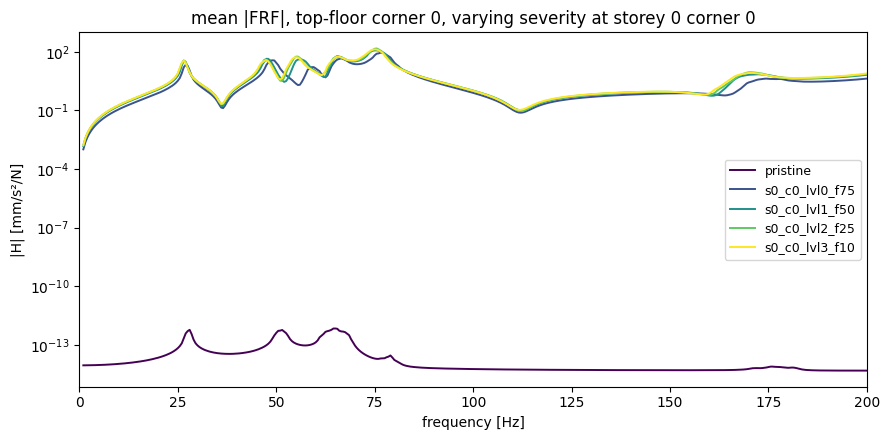

In [6]:
# pull out a single channel (top-floor corner 0) for every sample
sensor_idx = 12   # plate 3 (top), corner 0
all_mag = np.stack([np.abs(frf_collection.measurements[i][:, sensor_idx, 0])
                    for i in range(len(frf_collection))])
labels = np.array([float(frf_collection.labels[i][()]) for i in range(len(frf_collection))])

target_col = (0, 0)                          # storey 0, corner 0 - watch this column
focus = [0]                                  # pristine
for L in range(len(DS.DAMAGE_LEVELS)):
    name = f"s{target_col[0]}_c{target_col[1]}_lvl{L}"
    for sc in scenarios:
        if sc.name.startswith(name):
            focus.append(sc.label); break

fig, ax = plt.subplots(figsize=(9, 4.5))
cmap = plt.get_cmap('viridis')
for k, lbl in enumerate(focus):
    sel = labels == lbl
    sc_name = scenarios[lbl].name
    ax.semilogy(freq_axis, all_mag[sel].mean(0),
                color=cmap(k / max(len(focus) - 1, 1)),
                label=sc_name, linewidth=1.4)
ax.set_xlabel('frequency [Hz]'); ax.set_ylabel('|H| [mm/s²/N]')
ax.set_title('mean |FRF|, top-floor corner 0, varying severity at storey 0 corner 0')
ax.set_xlim(0, 200); ax.legend(fontsize=9); plt.tight_layout(); plt.show()


## 6. Three diagnostic heads

All three heads are trained on the **same FRF features** (log-magnitude +
unwrapped phase per channel) and use the **same train / val / test split**
(stratified on the 49-class scenario label, so every class is represented
in every split):

1. **Detection** — binary classifier: pristine vs any damage.
2. **Localisation** — 12-way classifier: which of the 12 columns is thinned.
   Damaged subset only.
3. **Severity** — *regression* on the **loss of rigidity** of the damaged
   column, ``L = 1 - factor⁴`` ∈ [0, 1] (where ``factor`` is the
   section-scale factor of the damaged column and the lateral stiffness of
   a uniformly thinned column scales as ``factor⁴``). Damaged subset only;
   the four discrete training levels yield ``L ∈ {0.684, 0.938, 0.996,
   1.000}`` but the head is free to interpolate at evaluation time.


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

# stratified split on the 49-way scenario label
train_idx, val_idx, test_idx = frf_collection.split(0.70, 0.15, 0.15, seed=0)
print(f"split: {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test")

# per-sample auxiliary labels for the three heads
n = len(frf_collection)
sample_label = np.array([int(frf_collection.labels[i][()]) for i in range(n)])
sample_is_dmg = is_dmg[sample_label]
sample_col    = col_label[sample_label]
sample_sev    = sev_label[sample_label]
sample_factor = factor_label[sample_label]          # regression *target* for head 3
sample_rig    = rig_loss[sample_label]              # reported quantity at eval time

def to_features(arr):
    '''Log-magnitude + unwrapped phase, normalised globally (not per-channel)
    so that cross-sensor amplitude differences - which is what disambiguates
    mirror-image damage locations - survive.'''
    z = np.asarray(arr).reshape(arr.shape[0], -1).T          # (channels, n_freq)
    mag = np.log1p(np.abs(z))
    mag = (mag - mag.mean()) / (mag.std() + 1e-12)
    phase = np.unwrap(np.angle(z), axis=1)
    phase = phase / (np.abs(phase).max() + 1e-12)
    return torch.from_numpy(np.concatenate([mag, phase], axis=0).astype(np.float32))

frf_collection.torch_dataset()
ds = frf_collection.dataset
ds.transform = to_features
print('feature shape:', ds[0][0].shape)


split: 3430 train / 735 val / 735 test


feature shape: torch.Size([64, 399])


In [8]:
class FRFClassifier(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.net(x)


class HeadDataset(torch.utils.data.Dataset):
    '''Wraps the underlying HDF5Dataset and rewrites the label column.'''
    def __init__(self, base, indices, label_array):
        self.base = base
        self.idx = list(indices)
        self.lbl = label_array
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        global_i = self.idx[i]
        x, _ = self.base[global_i]
        return x, torch.tensor(self.lbl[global_i], dtype=torch.long)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_channels = ds[0][0].shape[0]
print('device =', device, '  channels =', n_channels)


def train_head(label_array, n_classes, mask, n_epochs=30, lr=2e-3, batch=64):
    '''Train one head on the subset of samples where ``mask[i]`` is True.'''
    tr = [i for i in train_idx if mask[i]]
    va = [i for i in val_idx   if mask[i]]
    te = [i for i in test_idx  if mask[i]]
    train_loader = DataLoader(HeadDataset(ds, tr, label_array), batch_size=batch, shuffle=True)
    val_loader   = DataLoader(HeadDataset(ds, va, label_array), batch_size=128)
    test_loader  = DataLoader(HeadDataset(ds, te, label_array), batch_size=128)

    model = FRFClassifier(n_channels, n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    loss_fn = nn.CrossEntropyLoss()

    def pass_(loader, train):
        model.train(train)
        tot, cor, ls = 0, 0, 0.0
        for x, y in loader:
            x = x.to(device); y = y.to(device)
            if train: opt.zero_grad()
            logits = model(x); loss = loss_fn(logits, y)
            if train: loss.backward(); opt.step()
            ls += loss.item() * x.size(0); cor += (logits.argmax(1) == y).sum().item(); tot += x.size(0)
        return ls / tot, cor / tot

    history = []
    for ep in range(1, n_epochs + 1):
        tl, ta = pass_(train_loader, True)
        with torch.no_grad():
            vl, va_acc = pass_(val_loader, False)
        sched.step()
        history.append((tl, ta, vl, va_acc))
        if ep == 1 or ep % 5 == 0 or ep == n_epochs:
            print(f"  ep {ep:>3d}  tr loss {tl:.3f} acc {ta:.2%}   "
                  f"val loss {vl:.3f} acc {va_acc:.2%}")

    # collect test predictions
    ys, yps = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            ys.append(y.numpy())
            yps.append(model(x.to(device)).argmax(1).cpu().numpy())
    ys = np.concatenate(ys); yps = np.concatenate(yps)
    return model, np.array(history), ys, yps


device = cpu   channels = 64


In [9]:
print("HEAD 1 — DETECTION (pristine vs damaged)")
det_mask = np.ones(n, dtype=bool)                      # use all samples
det_label = sample_is_dmg.astype(int)
det_model, det_hist, det_y, det_yp = train_head(det_label, 2, det_mask, n_epochs=15)


HEAD 1 — DETECTION (pristine vs damaged)


  ep   1  tr loss 0.089 acc 97.96%   val loss 0.017 acc 97.96%


  ep   5  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  ep  10  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  ep  15  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


In [10]:
print("HEAD 2 — LOCALISATION (which of the 12 columns is thinned)")
loc_mask = sample_is_dmg == 1                          # damaged samples only
loc_label = sample_col.copy()
loc_label[~loc_mask] = 0                               # placeholder for indexing safety
loc_model, loc_hist, loc_y, loc_yp = train_head(loc_label, 12, loc_mask, n_epochs=25)


HEAD 2 — LOCALISATION (which of the 12 columns is thinned)


  ep   1  tr loss 1.566 acc 35.98%   val loss 0.724 acc 63.75%


  ep   5  tr loss 0.009 acc 99.97%   val loss 0.001 acc 100.00%


  ep  10  tr loss 0.002 acc 99.97%   val loss 0.000 acc 100.00%


  ep  15  tr loss 0.001 acc 100.00%   val loss 0.000 acc 100.00%


  ep  20  tr loss 0.001 acc 99.97%   val loss 0.000 acc 100.00%


  ep  25  tr loss 0.001 acc 100.00%   val loss 0.000 acc 100.00%


In [11]:
class FRFRegressor(nn.Module):
    '''Same backbone as the classifier, single linear output. We train it on
    the column section-scale factor (well-spread in [0.10, 0.75]) and convert
    to loss of rigidity ``1 - factor**4`` at evaluation time. Predicting the
    loss directly collapses to a constant because three of the four training
    targets sit near 1 (the lateral stiffness drops as factor**4, so factors
    0.5/0.25/0.1 give losses 0.94 / 0.996 / 0.9999 - barely separable).'''
    def __init__(self, n_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class RegressionHeadDataset(torch.utils.data.Dataset):
    '''Like HeadDataset, but returns a float target.'''
    def __init__(self, base, indices, target_array):
        self.base = base; self.idx = list(indices); self.tgt = target_array
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        gi = self.idx[i]; x, _ = self.base[gi]
        return x, torch.tensor(self.tgt[gi], dtype=torch.float32)


def train_regression_head(target_array, mask, n_epochs=30, lr=2e-3, batch=64):
    tr = [i for i in train_idx if mask[i]]
    va = [i for i in val_idx   if mask[i]]
    te = [i for i in test_idx  if mask[i]]
    train_loader = DataLoader(RegressionHeadDataset(ds, tr, target_array), batch_size=batch, shuffle=True)
    val_loader   = DataLoader(RegressionHeadDataset(ds, va, target_array), batch_size=128)
    test_loader  = DataLoader(RegressionHeadDataset(ds, te, target_array), batch_size=128)

    model = FRFRegressor(n_channels).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    loss_fn = nn.MSELoss()

    def pass_(loader, train):
        model.train(train)
        tot, ae = 0, 0.0
        for x, y in loader:
            x = x.to(device); y = y.to(device)
            if train: opt.zero_grad()
            pred = model(x); loss = loss_fn(pred, y)
            if train: loss.backward(); opt.step()
            ae += (pred - y).abs().sum().item(); tot += x.size(0)
        return ae / tot

    history = []
    for ep in range(1, n_epochs + 1):
        tmae = pass_(train_loader, True)
        with torch.no_grad():
            vmae = pass_(val_loader, False)
        sched.step()
        history.append((tmae, vmae))
        if ep == 1 or ep % 5 == 0 or ep == n_epochs:
            print(f"  ep {ep:>3d}  tr MAE {tmae:.4f}   val MAE {vmae:.4f}")

    ys, yps = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            ys.append(y.numpy())
            yps.append(model(x.to(device)).cpu().numpy())
    return model, np.array(history), np.concatenate(ys), np.concatenate(yps)


print("HEAD 3 — SEVERITY (regression on loss of rigidity)")
sev_mask = sample_is_dmg == 1
sev_target = sample_factor.astype(np.float32)        # train on factor
sev_model, sev_hist, sev_y_factor, sev_yp_factor = train_regression_head(
    sev_target, sev_mask, n_epochs=30)
# Convert to loss of rigidity for reporting
sev_yp_factor = np.clip(sev_yp_factor, 0.0, 1.0)
sev_y  = 1.0 - sev_y_factor  ** 4                    # true loss
sev_yp = 1.0 - sev_yp_factor ** 4                    # predicted loss


HEAD 3 — SEVERITY (regression on loss of rigidity)


  ep   1  tr MAE 0.2492   val MAE 0.2239


  ep   5  tr MAE 0.1096   val MAE 0.1085


  ep  10  tr MAE 0.1039   val MAE 0.0898


  ep  15  tr MAE 0.0967   val MAE 0.0928


  ep  20  tr MAE 0.0867   val MAE 0.0792


  ep  25  tr MAE 0.0837   val MAE 0.0754


  ep  30  tr MAE 0.0802   val MAE 0.0744


## 7. Test-set evaluation

Two confusion matrices for the classifier heads, and a predicted-vs-true
scatter for the severity regressor (with the four discrete training values
of ``L = 1 - factor⁴`` shown as horizontal references).


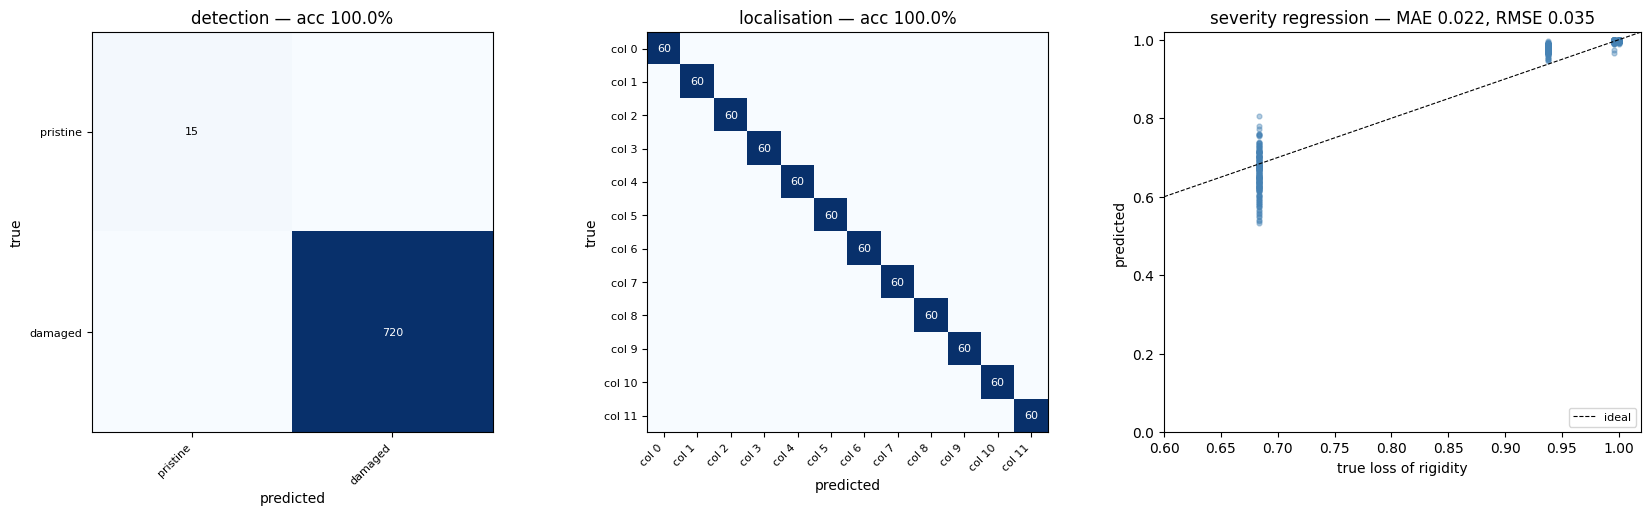

severity — per-level test-set statistics:
  factor 0.75   true L = 0.6836   pred mean 0.6620, std 0.0515   MAE 0.0438
  factor 0.50   true L = 0.9375   pred mean 0.9770, std 0.0086   MAE 0.0395
  factor 0.25   true L = 0.9961   pred mean 0.9969, std 0.0035   MAE 0.0022
  factor 0.10   true L = 0.9999   pred mean 0.9975, std 0.0017   MAE 0.0024


In [12]:
from sklearn.metrics import confusion_matrix

def plot_cm(ax, ys, yps, classes, title):
    cm = confusion_matrix(ys, yps, labels=list(range(len(classes))))
    acc = (ys == yps).mean()
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(f'{title} — acc {acc:.1%}')
    mx = cm.max() if cm.max() else 1
    for i in range(len(classes)):
        for j in range(len(classes)):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha='center', va='center',
                         color='white' if cm[i, j] > mx / 2 else 'black',
                         fontsize=8)
    return cm, acc


def plot_severity(ax, y_true, y_pred):
    '''Predicted vs true loss of rigidity, one box per discrete training level.'''
    levels = sorted(set(np.round(y_true, 4).tolist()))
    ax.axline((0, 0), (1, 1), color='black', linewidth=0.8, linestyle='--', label='ideal')
    for L in levels:
        sel = np.isclose(y_true, L, atol=1e-3)
        if not sel.any():
            continue
        ax.scatter(np.full(sel.sum(), L), y_pred[sel],
                    color='steelblue', alpha=0.4, s=12)
    mae = float(np.abs(y_pred - y_true).mean())
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    ax.set_xlabel('true loss of rigidity'); ax.set_ylabel('predicted')
    ax.set_xlim(0.6, 1.02); ax.set_ylim(0, 1.02)
    ax.set_title(f'severity regression — MAE {mae:.3f}, RMSE {rmse:.3f}')
    ax.legend(loc='lower right', fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
plot_cm(axes[0], det_y, det_yp, ['pristine', 'damaged'], 'detection')
col_names = [f"col {c}" for c in range(12)]
plot_cm(axes[1], loc_y, loc_yp, col_names, 'localisation')
plot_severity(axes[2], sev_y, sev_yp)
plt.tight_layout(); plt.show()

# per-level summary for severity
print("severity — per-level test-set statistics:")
for L_idx, factor in enumerate(DS.DAMAGE_LEVELS):
    L = 1 - factor ** 4
    sel = np.isclose(sev_y, L, atol=1e-3)
    if sel.any():
        mu = sev_yp[sel].mean(); sd = sev_yp[sel].std()
        print(f"  factor {factor:.2f}   true L = {L:.4f}   "
              f"pred mean {mu:.4f}, std {sd:.4f}   "
              f"MAE {np.abs(sev_yp[sel]-L).mean():.4f}")


## 8. Persist the trained heads

Each `pymodal.frf` collection now owns its trained models. `save_model`
serialises a PyTorch state dict to a `.pt` file *next to* the HDF5 and
records the path under `/attached/{role}` in the collection's HDF5 file -
the model itself stays a separate file on disk, but the collection knows
how to find it. `load_model` reverses the round-trip.


In [13]:
det_pt = frf_collection.save_model(det_model, role='detection')
loc_pt = frf_collection.save_model(loc_model, role='localisation')
sev_pt = frf_collection.save_model(sev_model, role='severity')
print('attached files on this collection:')
for r in frf_collection.attached_roles():
    print(f'  {r:>13s} -> {frf_collection.attached_path(r)}')

# Round-trip one model and verify the prediction matches
restored = frf_collection.load_model(FRFClassifier, role='detection',
                                       n_channels=n_channels,
                                       n_classes=2).to(device)
with torch.no_grad():
    sample_x, _ = ds[0]
    p_orig = det_model(sample_x.unsqueeze(0).to(device)).argmax(1).item()
    p_load = restored(sample_x.unsqueeze(0).to(device)).argmax(1).item()
print(f'round-trip OK: original prediction {p_orig}, restored {p_load}, '
      f'match = {p_orig == p_load}')


attached files on this collection:
      detection -> /home/user/pymodal/examples/los_alamos_3story/los_alamos_dataset.detection.pt
   localisation -> /home/user/pymodal/examples/los_alamos_3story/los_alamos_dataset.localisation.pt
       severity -> /home/user/pymodal/examples/los_alamos_3story/los_alamos_dataset.severity.pt
round-trip OK: original prediction 0, restored 0, match = True


## 9. Swapping in FEA — same notebook, any mesh

The library now owns the generic glue (`pymodal.Scenario`,
`pymodal.ParameterVariation`, `pymodal.build_frf_collection`,
`pymodal.closest_node`, `pymodal.load_nodes_json`). Switching this notebook
from the reduced-order model to FEA on the existing Salome mesh is one
function:

```python
from frf_extract import extract_frf
from pymodal import load_nodes_json, closest_node

node_ids, coords = load_nodes_json(EXAMPLE_DIR / "nodes.json")

def fea_modal_provider(geom, freqs, ins, outs):
    in_pts  = [(p, d) for p, d in ins]
    out_pts = [(p, d) for p, d in outs]
    H = []
    for (p_in, d_in) in in_pts:
        col = []
        for (p_out, d_out) in out_pts:
            f = extract_frf(input_xyz=p_in, input_dir=d_in,
                             output_xyz=p_out, output_dir=d_out,
                             f_min=freqs[0], f_max=freqs[-1],
                             f_step=freqs[1] - freqs[0])
            col.append(f.measurements[0][:, 0, 0])
        H.append(np.stack(col, axis=1))             # (n_freq, n_out)
    return np.stack(H, axis=2)                      # (n_freq, n_out, n_in)

DS.build_dataset(scenarios, n_per_scenario=100, inputs=inputs, outputs=outputs,
                  freq_array=freq_axis, path=...,
                  modal_provider=fea_modal_provider)
```

For a different structure: replace the `BuildingGeometry` factory and the
LANL-specific `apply` callbacks; the classifier, dataset and confusion-matrix
code stay unchanged.

## Cleanup


In [14]:
frf_collection.open()
frf_collection.close(keep=True)
print(f"dataset preserved at {dataset_path}")


dataset preserved at /home/user/pymodal/examples/los_alamos_3story/los_alamos_dataset.h5
